In [1]:
import torch
from torch import optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
import random
import datetime

from deterministic_combined_with_augmentation import DunexDataset
from network import ResNetUNet
import torch
from visualize_dataset import plot_dataset_grid
from loss import calc_loss
import os
import gc

%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower



# torch.mps.caching_allocator_set_fraction(0.9)  # Set before training



In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNetUNet(n_class=1)
# model = torch.compile(model)  # Add this after model definition
model = model.to(device)


In [3]:
sequential_transects = 3
samples_per_image = 128
ds = DunexDataset(['cvat_annotations/triplets_fully_labeled/annotations_poly_updated.xml', 
                   'cvat_annotations/additional_data/annotations_poly.xml'],
                  samples_per_image = samples_per_image,
                  use_missing_data=True)
train, val = torch.utils.data.random_split(ds, (80 * samples_per_image, 5 * samples_per_image))
batch_size = 32

# Should be deterministic, might need to change to add more workers 
batch_size=32
dataloaders = {
    'train': DataLoader(train, 
                       batch_size=batch_size,
                       shuffle=True,
                       num_workers=4,  # 4 seems to bottleneck
                       pin_memory=True,
                       persistent_workers=True),
    'val': DataLoader(val, 
                     batch_size=batch_size,
                     shuffle=True,
                     num_workers=4,
                     pin_memory=True,
                     persistent_workers=True)
}


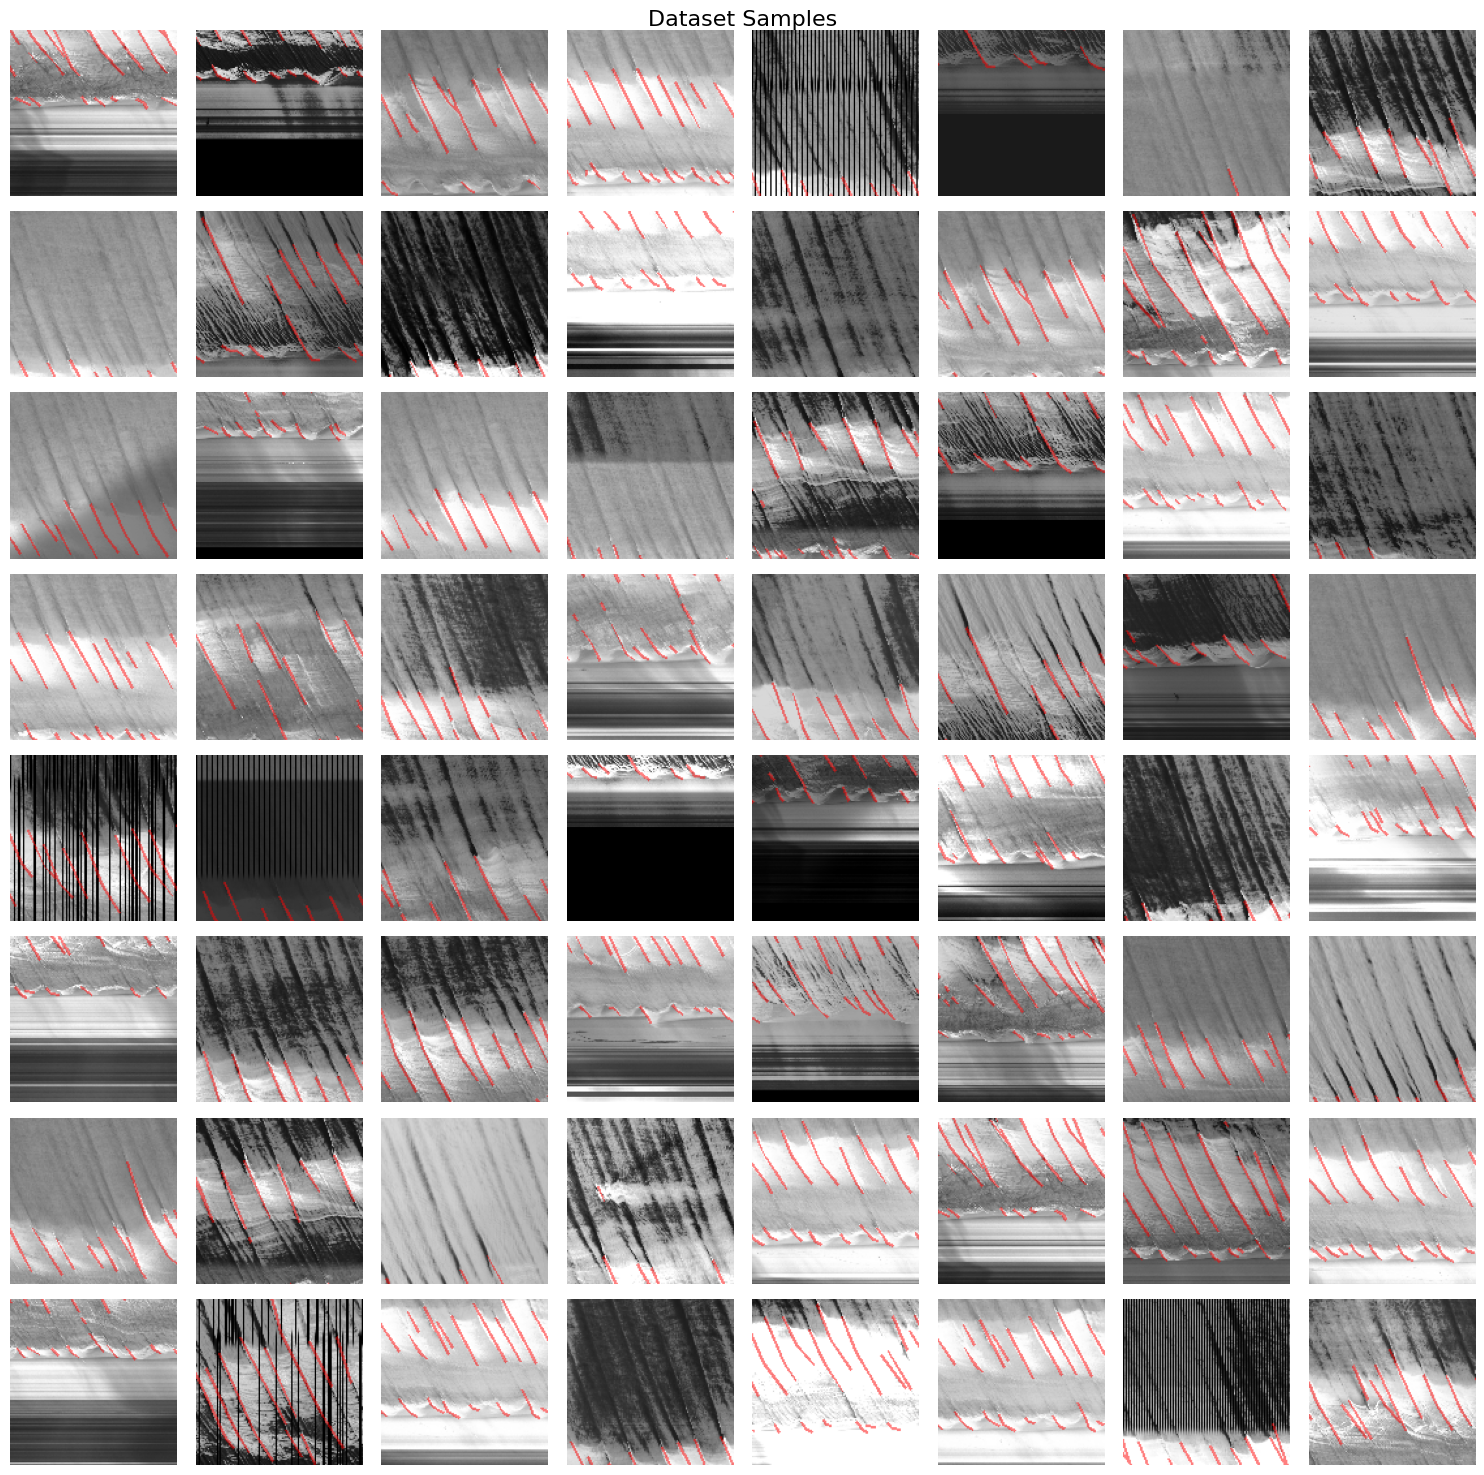

In [4]:
plot_dataset_grid(dataloaders['val'].dataset, 64, indices=2*np.arange(0, 64))

In [9]:
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm
import gc
import os
import signal
import datetime
from contextlib import contextmanager

@contextmanager
def dataloader_manager(dataloaders):
    """Context manager to properly handle dataloader cleanup"""
    try:
        yield dataloaders
    finally:
        # Ensure proper cleanup of workers
        for phase in dataloaders:
            if hasattr(dataloaders[phase], '_iterator'):
                iterator = dataloaders[phase]._iterator
                if iterator is not None:
                    iterator._shutdown_workers()

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, optimizer, scheduler, dataloaders, device, start_epoch=0, num_epochs=200):
    l = []
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    last_checkpoint = None

    # Wrap dataloader usage in context manager
    with dataloader_manager(dataloaders):
        try:
            for epoch in range(start_epoch, num_epochs):
                since = time.time()

                for phase in ['train', 'val']:
                    lr = 0
                    if phase == 'train':
                        for param_group in optimizer.param_groups:
                            lr = param_group['lr']
                        model.train()
                    else:
                        model.eval()

                    metrics = defaultdict(float)
                    epoch_samples = 0

                    with tqdm(dataloaders[phase], desc=f'epoch:{epoch} - {phase} -  lr:{lr}') as pbar:
                        for inputs, labels in pbar:
                            try:
                                inputs = inputs.to(device)
                                labels = labels.to(device)
                                
                                optimizer.zero_grad()

                                with torch.set_grad_enabled(phase == 'train'):
                                    outputs = model(inputs)
                                    loss = calc_loss(outputs, labels, metrics, epoch, 
                                                   start_boundary_epoch=num_epochs)

                                    if phase == 'train':
                                        loss.backward()
                                        optimizer.step()
                                        scheduler.step()
                                
                                epoch_samples += inputs.size(0)
                                pbar.set_postfix({'loss': loss.item()})

                            except Exception as e:
                                print(f"Error processing batch: {e}")
                                continue

                    # Update metrics
                    if epoch_samples > 0:  # Only update if we processed any samples
                        if phase == 'train':
                            train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            train_metrics['focal'].append(metrics['focal']/epoch_samples)
                            train_metrics['dice'].append(metrics['dice']/epoch_samples)
                            train_metrics['disc'].append(metrics['disc']/epoch_samples)
                            train_metrics['loss'].append(loss.detach().cpu())
                            
                        if phase == 'val':
                            validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                            validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                            validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                            validation_metrics['loss'].append(loss.detach().cpu())

                        print_metrics(metrics, epoch_samples, phase)
                        epoch_loss = metrics['loss'] / epoch_samples
                        
                        if phase == 'val':
                            l.append(epoch_loss)
                            if epoch_loss < best_loss:
                                best_loss = epoch_loss
                                best_model_wts = copy.deepcopy(model.state_dict())
                                
                                if last_checkpoint is not None and os.path.exists(last_checkpoint):
                                    try:
                                        os.remove(last_checkpoint)
                                    except OSError as e:
                                        print(f"Error removing old checkpoint: {e}")
                                print('Saving')
                                last_checkpoint = f'training_checkpoint_model4_epoch{epoch}_{datetime.date.today().strftime("%Y%m%d")}.pt'
                                torch.save(model.state_dict(), last_checkpoint)

                # Memory cleanup
                gc.collect()
                if hasattr(torch, 'mps'):
                    torch.mps.empty_cache()
                elif hasattr(torch, 'cuda'):
                    torch.cuda.empty_cache()

                time_elapsed = time.time() - since

        except KeyboardInterrupt:
            print("\nTraining interrupted by user. Saving current state...")
            if last_checkpoint is None:
                last_checkpoint = f'interrupted_checkpoint_{datetime.date.today().strftime("%Y%m%d")}.pt'
            torch.save(model.state_dict(), last_checkpoint)
            raise

        finally:
            print('Best val loss: {:4f}'.format(best_loss))
            model.load_state_dict(best_model_wts)

    return model, l, train_metrics, validation_metrics

epoch:0 - train -  lr:0.0007464000000000012: 100%|██████████| 320/320 [02:01<00:00,  2.64it/s, loss=0.261]


train: focal: 0.051029, dice: 0.546853, loss: 0.298941, boundary: 0.000000, disc: 0.000000


epoch:0 - val -  lr:0: 100%|██████████| 20/20 [00:10<00:00,  1.99it/s, loss=0.237]


val: focal: 0.056527, dice: 0.444383, loss: 0.250455, boundary: 0.000000, disc: 0.000000


epoch:1 - train -  lr:0.0007494694315139418: 100%|██████████| 320/320 [01:56<00:00,  2.74it/s, loss=0.229]


...

val: focal: 0.095019, dice: 0.932115, loss: 0.679942, disc: 0.929504, boundary: 0.000000


epoch:299 - train -  lr:1.4867713668167333e-06: 100%|██████████| 320/320 [01:37<00:00,  3.29it/s, loss=0.68] 


train: focal: 0.094995, dice: 0.931218, loss: 0.679632, disc: 0.929420, boundary: 0.000000


epoch:299 - val -  lr:0: 100%|██████████| 20/20 [00:02<00:00,  9.58it/s, loss=0.679]


val: focal: 0.095020, dice: 0.932115, loss: 0.679942, disc: 0.929503, boundary: 0.000000
Best val loss: 0.057683


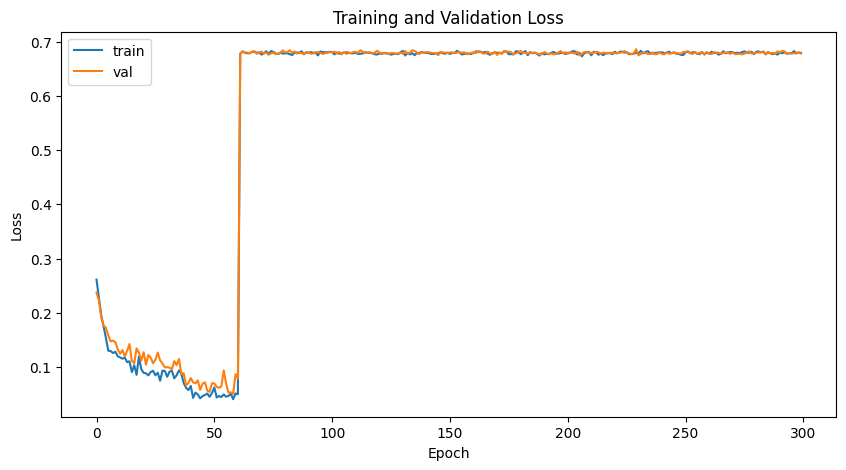

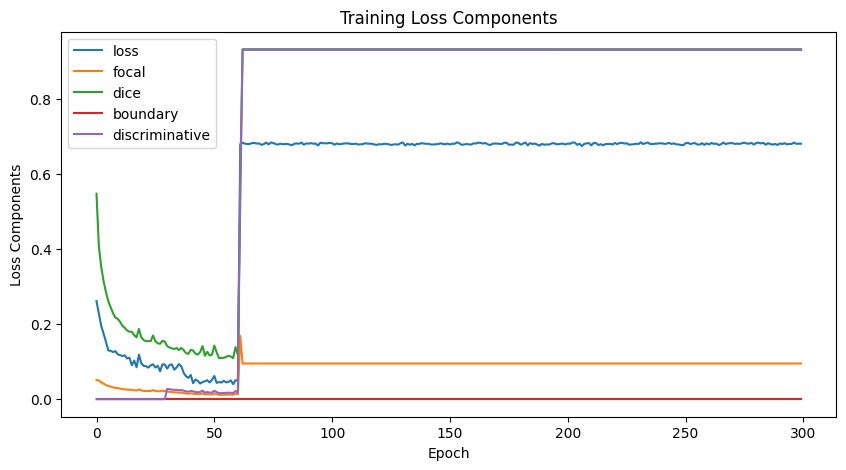

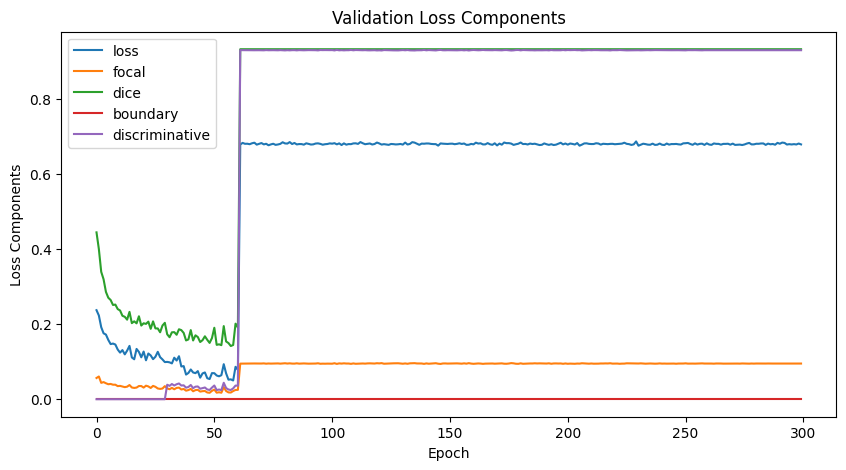

In [10]:
from loss import *

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

num_class = 1
model = ResNetUNet(num_class).to(device)

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)

epochs = 200

from torch.optim.lr_scheduler import OneCycleLR
# scheduler = OneCycleLR(optimizer_ft, 
#                        max_lr=5e-3,  # Increased from 1e-3
#                        epochs=epochs,    # Train longer
#                        steps_per_epoch=len(dataloaders['train']),
#                        div_factor=10, # Smaller div_factor for higher starting LR
#                        final_div_factor=1e2, # Less aggressive final LR reduction
#                        pct_start=0.2,  # Shorter warmup
#                        anneal_strategy='linear') # Linear annealing

epochs = 300
suggested_lr = 9.33e-03
# optimizer = Adam(model.parameters(), lr=suggested_lr)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)

scheduler = OneCycleLR(
    optimizer_ft,
    max_lr=suggested_lr * 2,
    epochs=epochs,
    steps_per_epoch=len(dataloaders['train']),
    pct_start=0.4,
    anneal_strategy='cos'
)

model, loss_history, train_metrics, val_metrics = train_model(
    model, 
    optimizer_ft, 
    scheduler, 
    dataloaders,
    device,
    start_epoch=0, 
    num_epochs=epochs
)
torch.save(model.state_dict(), f'best_model_{datetime.date.today().strftime('%Y%m%d')}.pt')

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Training Loss Components')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Validation Loss Components')
plt.legend()

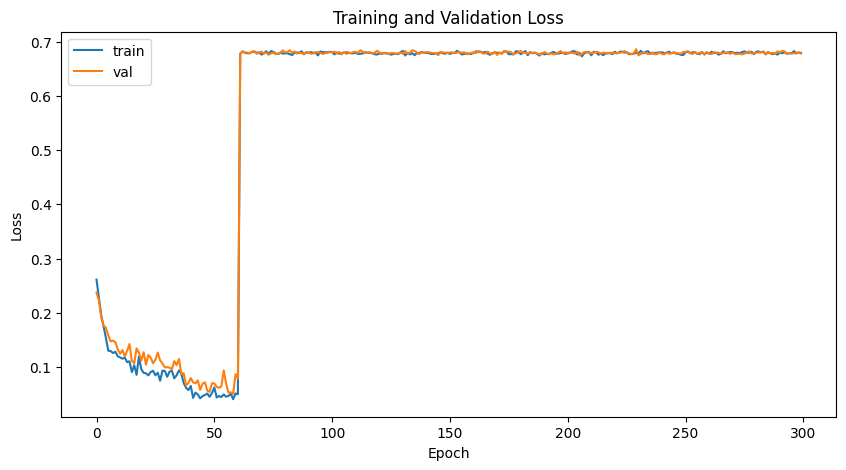

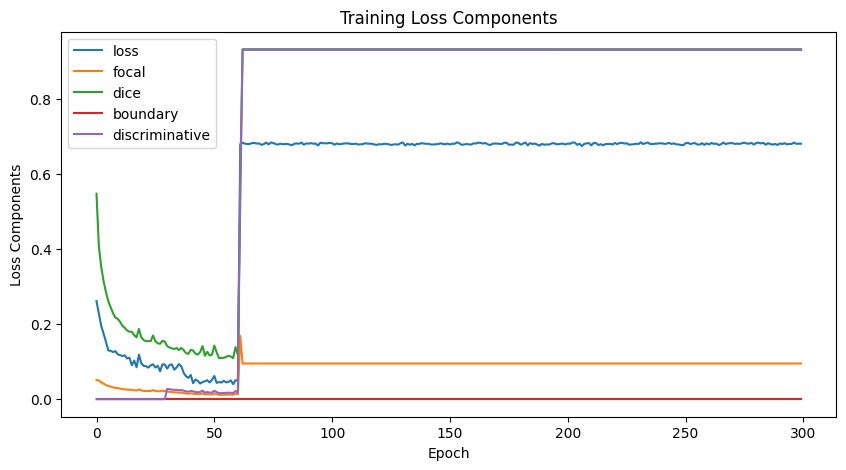

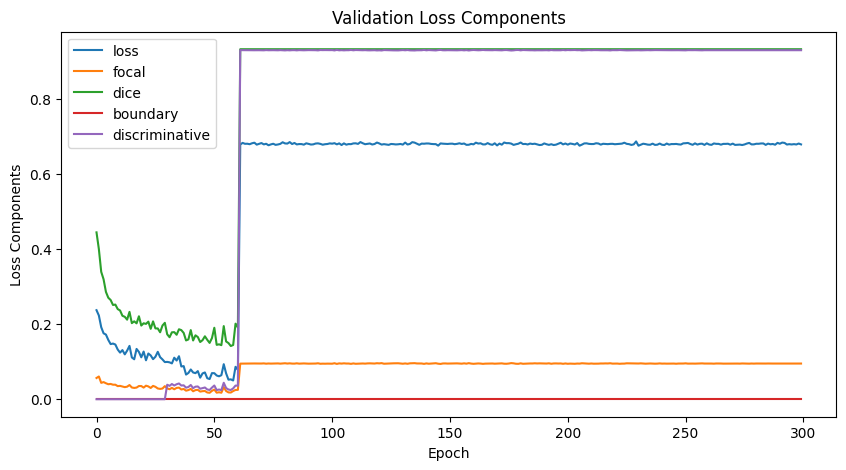

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Training Loss Components')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Validation Loss Components')
plt.legend()

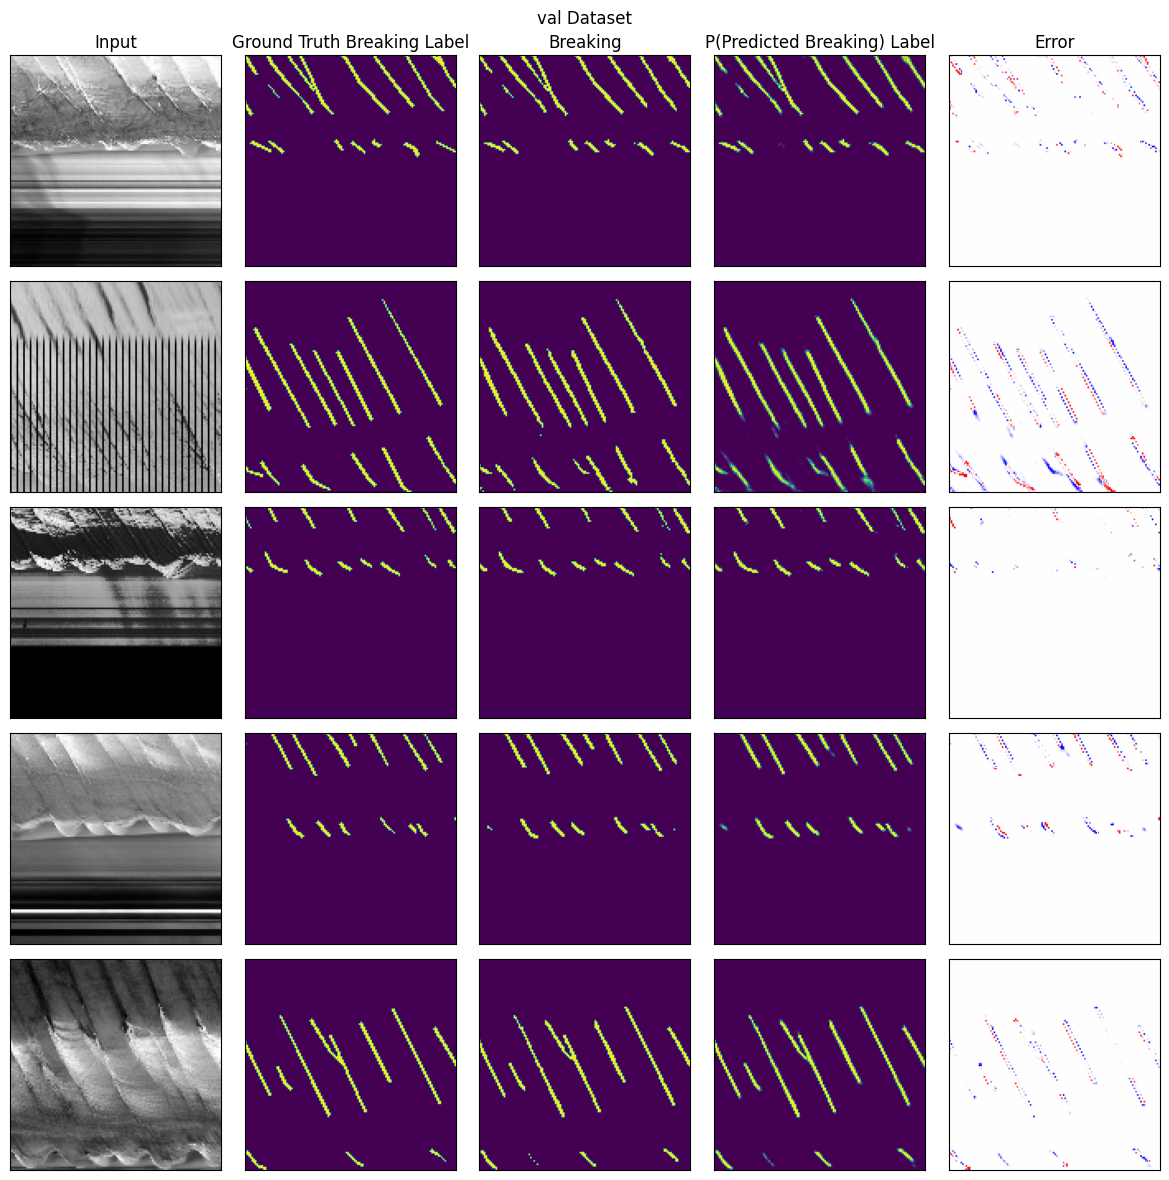

In [18]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='val'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')

fig.suptitle(f'{d} Dataset')
plt.tight_layout()
plt.show()
